In [1]:
import pandas as pd
data = pd.read_csv(r'C:\Users\Gouthami\Documents\DSML\Patient_risk_prediction\data\diabetes_prediction_dataset.csv')

In [2]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
data.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [7]:
cat_col = []
for col in data.columns:
    if (data[col].dtype == 'str'):
        cat_col.append(col)
        print(data[col].value_counts())
        print("\n")

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64




In [8]:
import seaborn as sns

In [9]:
import matplotlib.pyplot as plt

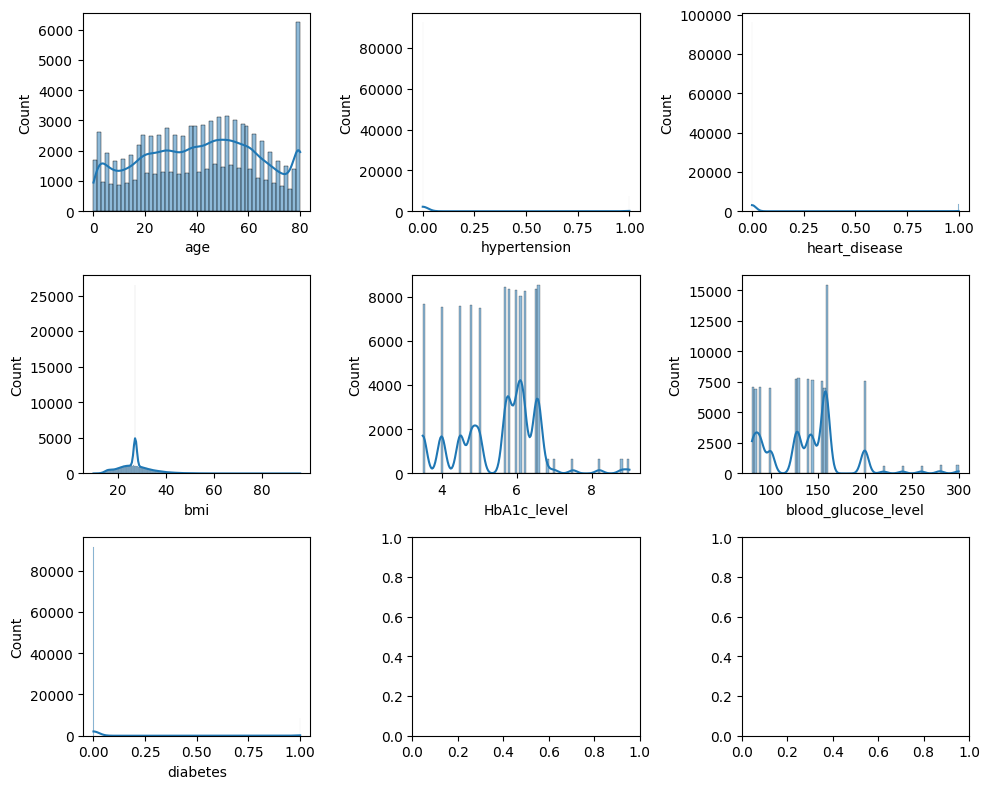

In [10]:
num_col = []
i = -1
fig, axes = plt.subplots(3,3, figsize = (10,8))
axes = axes.flatten()
for col in data.columns:
    if(data[col].dtype != 'str'):
        i += 1
        num_col.append(col)
        sns.histplot(data=data, x=col, kde=True, ax=axes[i])
plt.tight_layout() 
plt.show()

In [11]:
#should I have done at nunique step
cat_col.extend(['hypertension', 'heart_disease'])

In [12]:
cat_col

['gender', 'smoking_history', 'hypertension', 'heart_disease']

In [13]:
num_col.remove('diabetes')
num_col.remove('hypertension')
num_col.remove('heart_disease')
num_col

['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

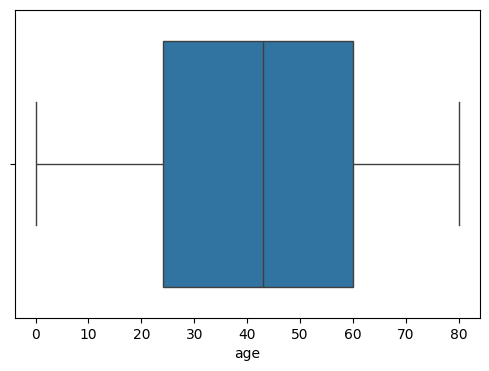

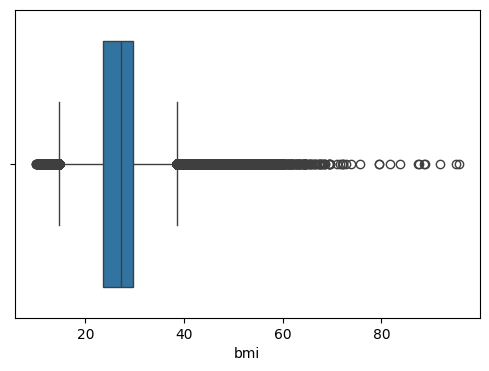

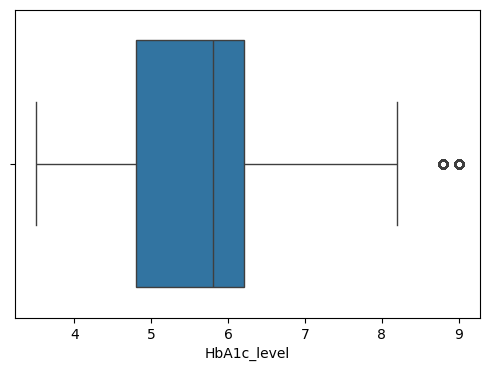

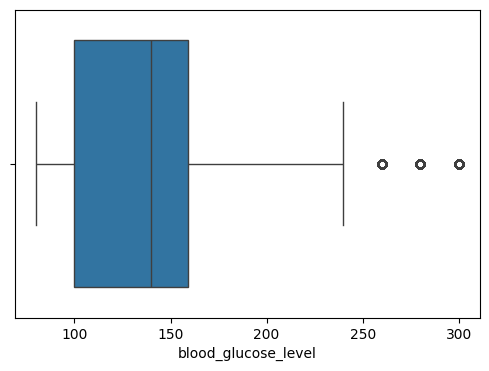

In [20]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data, x=col)
    plt.show()

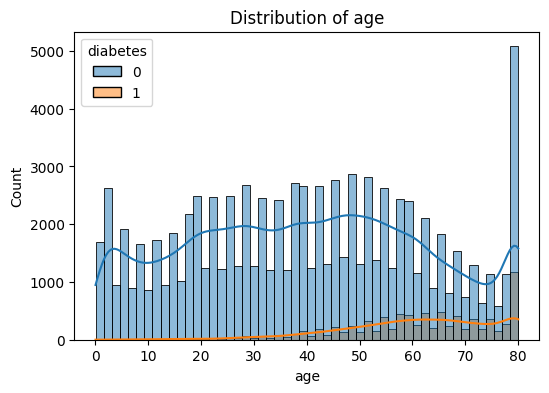

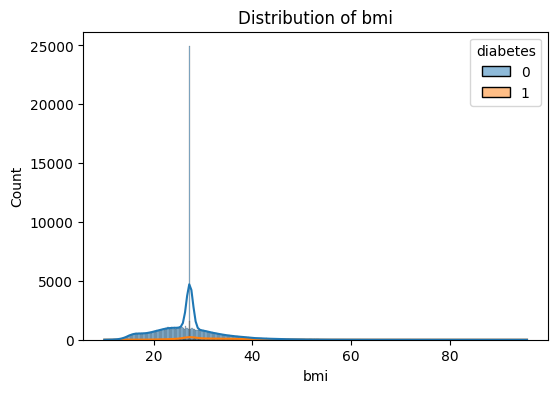

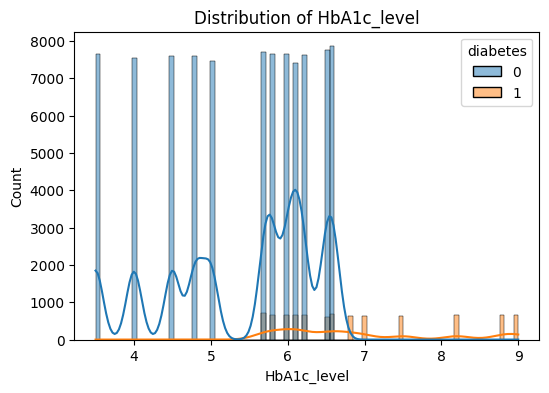

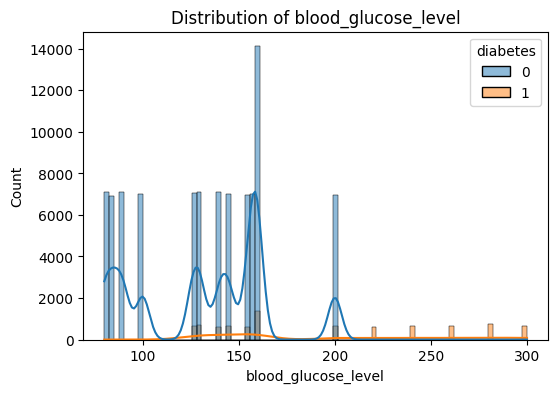

In [21]:
for col in num_col:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(
        data=data,
        x=col,
        hue='diabetes',
        kde=True
    )
    
    plt.title(f'Distribution of {col}')
    plt.show()

In [23]:
data['diabetes'].value_counts(normalize=True)

diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

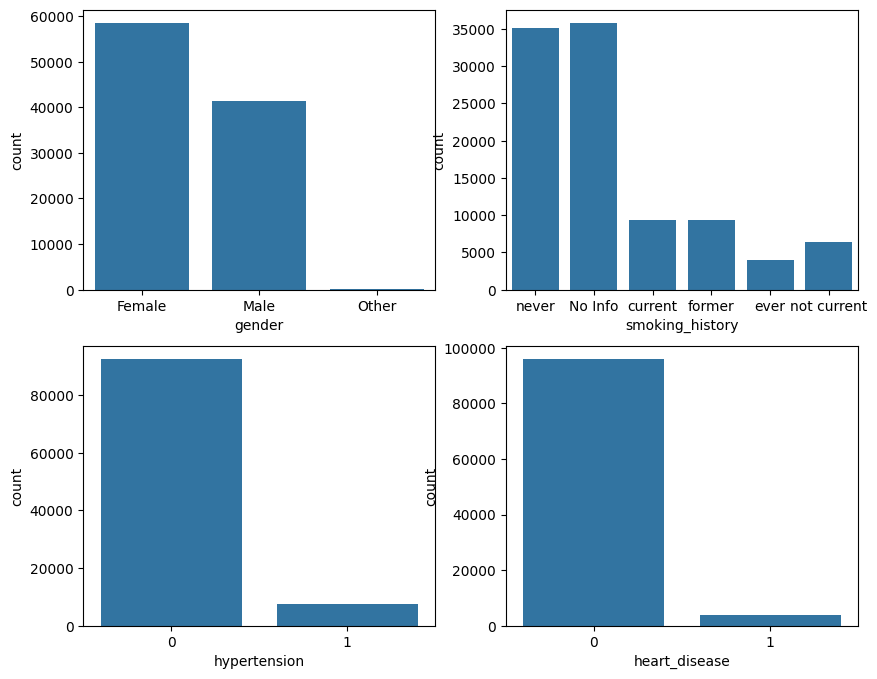

In [29]:
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()  
for i, col in enumerate(cat_col):
    sns.countplot(data=data, x=col, ax=axes[i])
plt.show()

In [28]:
for col in cat_col:
    print(data[col].value_counts())
    print("\n")

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


hypertension
0    92515
1     7485
Name: count, dtype: int64


heart_disease
0    96058
1     3942
Name: count, dtype: int64




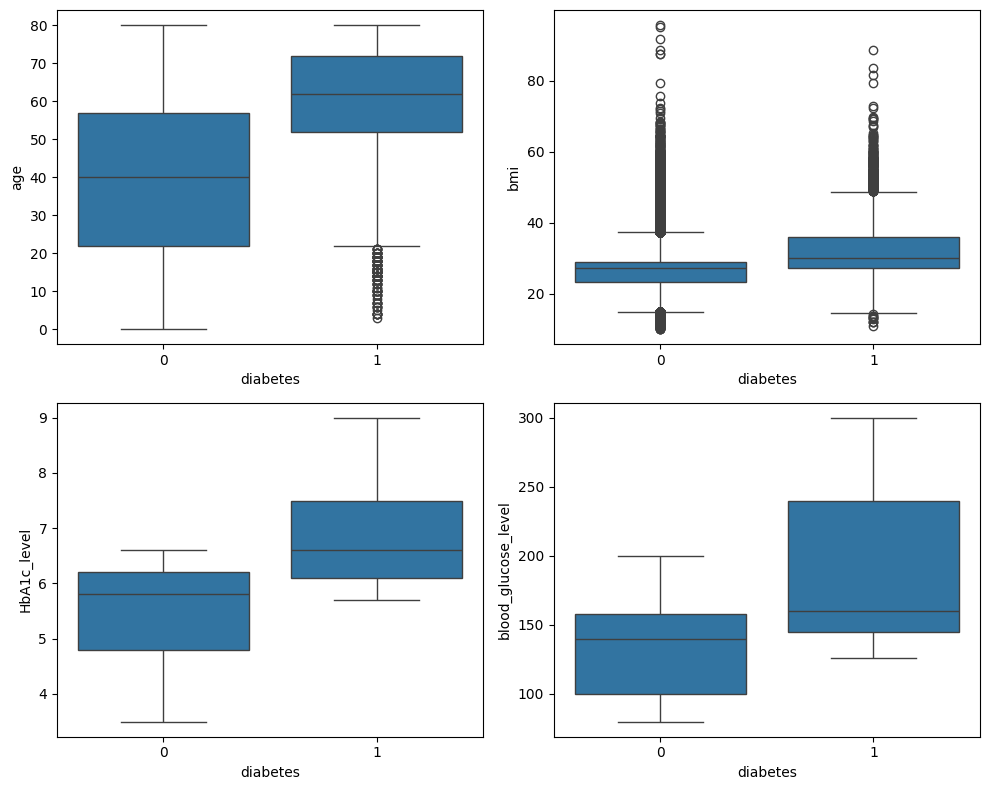

In [30]:
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()
for i,col in enumerate(num_col):
    sns.boxplot(data=data, x='diabetes', y = col, ax=axes[i])
plt.tight_layout()
plt.show()

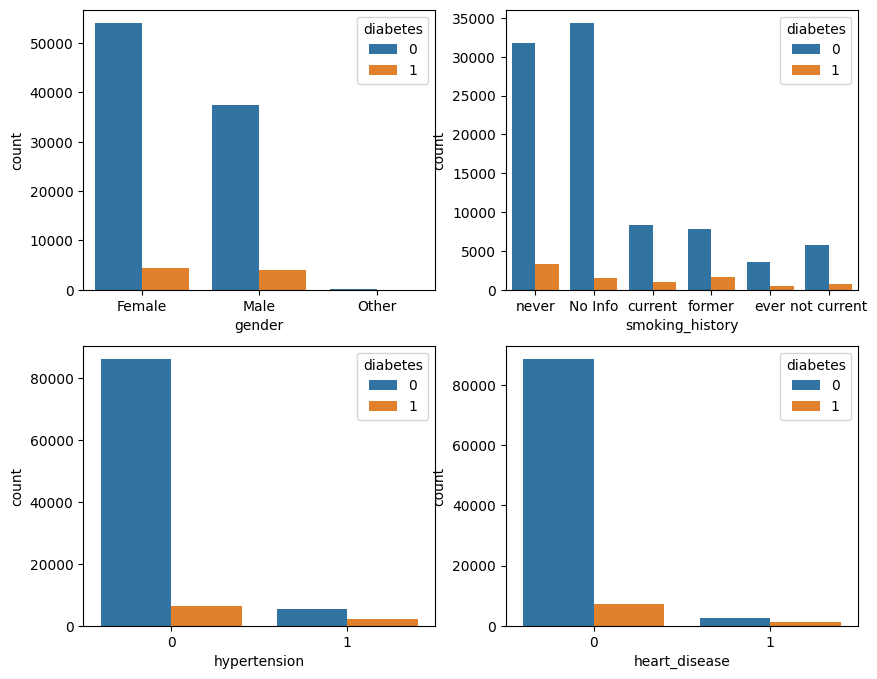

In [31]:
fig, axes = plt.subplots(2,2, figsize = (10,8))
axes = axes.flatten()  
for i, col in enumerate(cat_col):
    sns.countplot(data=data, x=col, hue='diabetes', ax=axes[i])
plt.show()

In [33]:
for col in cat_col:
    print(pd.crosstab(data[col], data['diabetes'], normalize='index'))
    print("\n")

diabetes         0         1
gender                      
Female    0.923811  0.076189
Male      0.902510  0.097490
Other     1.000000  0.000000


diabetes                0         1
smoking_history                    
No Info          0.959404  0.040596
current          0.897911  0.102089
ever             0.882118  0.117882
former           0.829983  0.170017
never            0.904659  0.095341
not current      0.892973  0.107027


diabetes             0         1
hypertension                    
0             0.930692  0.069308
1             0.721042  0.278958


diabetes              0         1
heart_disease                    
0              0.924702  0.075298
1              0.678590  0.321410




In [34]:
for col in cat_col:
    print(pd.crosstab(data['diabetes'], data[col], normalize='index'))
    print("\n")

gender      Female      Male     Other
diabetes                              
0         0.591158  0.408645  0.000197
1         0.524824  0.475176  0.000000


smoking_history   No Info   current      ever    former     never  not current
diabetes                                                                      
0                0.375541  0.091126  0.038601  0.084831  0.346984     0.062918
1                0.171059  0.111529  0.055529  0.187059  0.393647     0.081176


hypertension         0         1
diabetes                        
0             0.941016  0.058984
1             0.754353  0.245647


heart_disease         0         1
diabetes                         
0              0.970765  0.029235
1              0.850941  0.149059




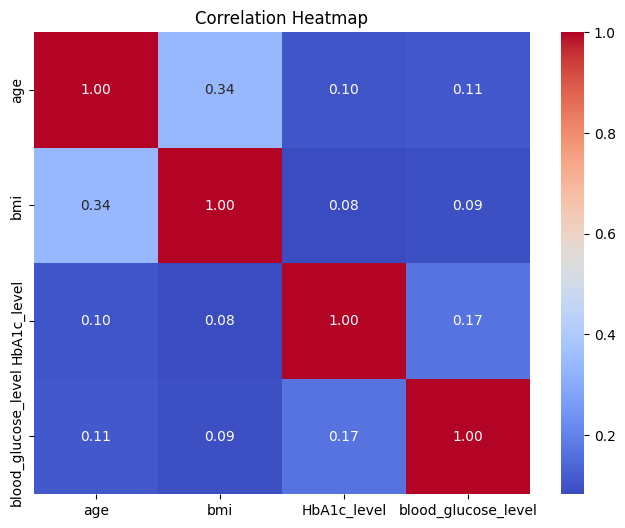

In [35]:
# correlation matrix
corr_matrix = data[num_col].corr()

# plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


In [39]:
sample_data = data.sample(5000, random_state=42)

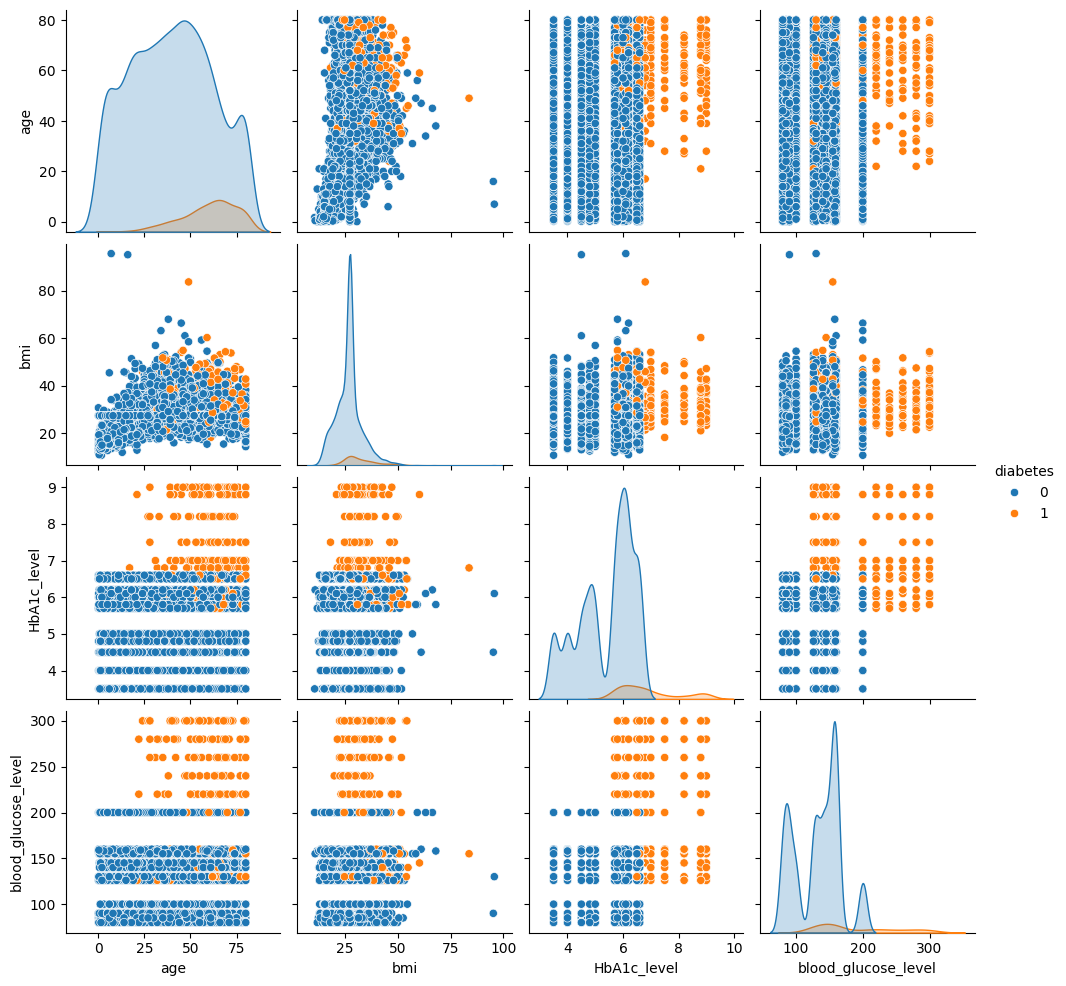

In [ ]:
#They are more useful when:

#feature relationships are central
#clusters may exist
#low-dimensional continuous data
#visual separability matters
sns.pairplot(
    data=sample_data,
    vars=num_col,
    hue='diabetes'
)
plt.show()

In [41]:
for i in range(len(cat_col)):
    for j in range(i+1, len(cat_col)):
        print(f"\nRelationship: {cat_col[i]} vs {cat_col[j]}\n")
        print(
            pd.crosstab(
                data[cat_col[i]],
                data[cat_col[j]],
                normalize='index'
            )
        )
        print("\n" + "-"*80)


Relationship: gender vs smoking_history

smoking_history   No Info   current      ever    former     never  not current
gender                                                                        
Female           0.336453  0.086385  0.038222  0.081534  0.390576     0.066829
Male             0.388849  0.102052  0.042602  0.110500  0.295028     0.060970
Other            0.333333  0.000000  0.055556  0.000000  0.166667     0.444444

--------------------------------------------------------------------------------

Relationship: gender vs hypertension

hypertension         0         1
gender                          
Female        0.928320  0.071680
Male          0.920637  0.079363
Other         1.000000  0.000000

--------------------------------------------------------------------------------

Relationship: gender vs heart_disease

heart_disease         0         1
gender                           
Female         0.973323  0.026677
Male           0.942554  0.057446
Other          1.00